# 🫁 Lung Cancer Risk Dataset — EDA & Predictive Modelling

**Goal**: Explore the lung cancer patient data, understand every feature (full description included), and build the **best ML classifier** to predict a patient's lung cancer risk `Level` (`Low` / `Medium` / `High`) using cross-validation and hyperparameter tuning inside a clean scikit-learn `Pipeline`.

---

## 1. 📖 Feature Description (Data Dictionary)

The dataset contains **24 features** and a target `Level`. Risk-factor columns are scored on a scale (higher value = stronger presence/exposure).

> ℹ️ `index` and `Patient Id` are only identifiers (not medically meaningful) → dropped later.

| Feature | Description |
|---------|-------------|
| `Age` | Age of the patient (years, numeric). |
| `Gender` | Gender of the patient. `1` / `2` (categorical — commonly 1 = Male, 2 = Female in this dataset). |
| `Air Pollution` | Level of air-pollution exposure. Higher = more exposure/pollution. |
| `Alcohol use` | Level of alcohol consumption. Higher = heavier drinking. |
| `Dust Allergy` | Level of dust allergy. Higher = more severe allergy. |
| `OccuPational Hazards` | Level of exposure to occupational hazards (chemicals, dust, fumes at work). Higher = more exposure. |
| `Genetic Risk` | Level of genetic predisposition/family history. Higher = stronger genetic risk. |
| `chronic Lung Disease` | Level of chronic lung disease (e.g. COPD). Higher = more severe disease. |
| `Balanced Diet` | Level of adherence to a balanced diet. Higher = more balanced/healthy. |
| `Obesity` | Level of obesity. Higher = more obese. |
| `Smoking` | Level of smoking. Higher = heavier smoker. |
| `Passive Smoker` | Level of passive/second-hand smoking exposure. Higher = more exposure. |
| `Chest Pain` | Level of chest pain. Higher = worse pain. |
| `Coughing of Blood` | Level of coughing up blood (haemoptysis — a classic lung-cancer red flag). Higher = worse. |
| `Fatigue` | Level of persistent fatigue/weakness. Higher = more fatigue. |
| `Weight Loss` | Level of unexplained weight loss. Higher = more severe weight loss. |
| `Shortness of Breath` | Level of dyspnea (breathlessness). Higher = worse. |
| `Wheezing` | Level of wheezing. Higher = worse. |
| `Swallowing Difficulty` | Level of dysphagia (trouble swallowing). Higher = worse. |
| `Clubbing of Finger Nails` | Level of finger-nail clubbing (bulbous fingertips — a lung-disease sign). Higher = more clubbing. |
| `Frequent Cold` | Level of how often the patient catches colds. Higher = more frequent. |
| `Dry Cough` | Level of dry cough. Higher = worse. |
| `Snoring` | Level of snoring. Higher = more frequent/loud. |
| **`Level` (target)** | **Lung cancer risk level**: `Low` / `Medium` / `High`. This is what we predict. |

### Why do these features matter for lung cancer?
The big, well-known drivers are **smoking**, **air pollution**, **occupational hazards** and **genetic risk**. The symptom/clinical features (`Coughing of Blood`, `Chest Pain`, `Shortness of Breath`, `Fatigue`, `Weight Loss`, `Wheezing`, `Clubbing of Finger Nails`, `Dry Cough`) are how lung cancer usually presents. By analysing the data we can see which factors push the risk from Low → Medium → High.

---

## 2. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, make_scorer
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# Multiclass ROC-AUC scorer (One-vs-Rest, macro average)
roc_auc_ovr = make_scorer(roc_auc_score, response_method='predict_proba',
                          multi_class='ovr', average='macro')

print('Setup complete.')

Setup complete.


## 3. Load the Data

In [2]:
# Load the dataset
data_path = 'cancer-patient-data-sets.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
df.head()

Shape: (1000, 26)


,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,Passive Smoker,Chest Pain,Coughing of Blood,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,2,4,3,2,2,4,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,2,2,2,4,2,3,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,6,7,2,3,4,8,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,7,7,7,7,7,8,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,7,7,8,7,7,9,3,2,4,1,4,2,4,2,3,High


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

In [4]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,1000.0,499.500,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,37.174,12.005493,14.0,27.75,36.0,45.00,73.0
Gender,1000.0,1.402,0.490547,1.0,1.00,1.0,2.00,2.0
Air Pollution,1000.0,3.840,2.030400,1.0,2.00,3.0,6.00,8.0
Alcohol use,1000.0,4.563,2.620477,1.0,2.00,5.0,7.00,8.0
Dust Allergy,1000.0,5.165,1.980833,1.0,4.00,6.0,7.00,8.0
OccuPational Hazards,1000.0,4.840,2.107805,1.0,3.00,5.0,7.00,8.0
Genetic Risk,1000.0,4.580,2.126999,1.0,2.00,5.0,7.00,7.0
chronic Lung Disease,1000.0,4.380,1.848518,1.0,3.00,4.0,6.00,7.0
Balanced Diet,1000.0,4.491,2.135528,1.0,2.00,4.0,7.00,7.0


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution (Low / Medium / High)

Level
High      365
Medium    332
Low       303
Name: count, dtype: int64

Percentage:
Level
High      36.5
Medium    33.2
Low       30.3
Name: proportion, dtype: float64


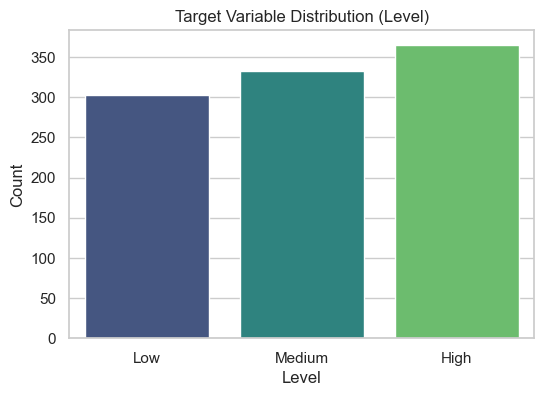

In [5]:
# Target distribution
print(df['Level'].value_counts())
print('\nPercentage:')
print((df['Level'].value_counts(normalize=True) * 100).round(2))

order = ['Low', 'Medium', 'High']
plt.figure(figsize=(6, 4))
sns.countplot(x='Level', data=df, order=order, palette='viridis')
plt.title('Target Variable Distribution (Level)')
plt.ylabel('Count')
plt.show()

### 4.2 Age & Gender Analysis

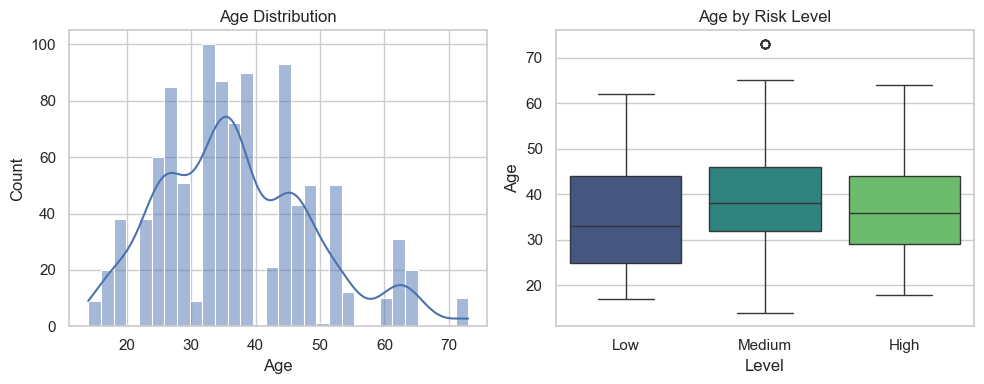

In [6]:
# Age distribution by Level
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x='Level', y='Age', data=df, order=order, palette='viridis')
plt.title('Age by Risk Level')
plt.tight_layout()
plt.show()

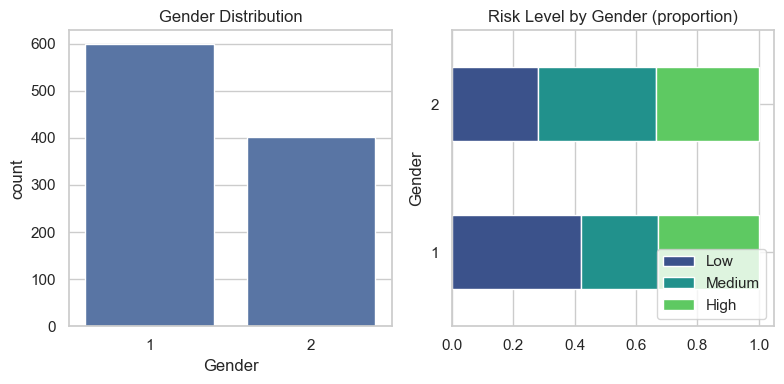

In [7]:
# Gender distribution and risk by gender
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')

plt.subplot(1, 2, 2)
pd.crosstab(df['Gender'], df['Level'], normalize='index').plot(
    kind='barh', stacked=True, ax=plt.gca(),
    color=sns.color_palette('viridis', 3))
plt.title('Risk Level by Gender (proportion)')
plt.legend(['Low', 'Medium', 'High'], loc='lower right')
plt.tight_layout()
plt.show()

### 4.3 Average Risk-Factor Profile by Level

This shows the mean score of each risk factor per risk level — the factors that clearly increase with risk are the important drivers.

Level                      Low  Medium  High
Air Pollution             2.60    2.93  5.69
Alcohol use               2.23    4.20  6.83
Dust Allergy              3.11    5.44  6.62
OccuPational Hazards      3.00    4.72  6.48
Genetic Risk              2.73    4.29  6.38
chronic Lung Disease      3.09    3.96  5.83
Balanced Diet             3.00    3.51  6.62
Obesity                   2.41    3.90  6.68
Smoking                   3.02    2.45  6.07
Passive Smoker            2.63    3.05  6.53
Chest Pain                2.83    3.75  6.39
Coughing of Blood         2.86    3.85  7.44
Fatigue                   2.17    3.49  5.59
Weight Loss               2.50    4.42  4.47
Shortness of Breath       2.50    4.63  5.33
Wheezing                  2.57    4.76  3.88
Swallowing Difficulty     2.76    4.16  4.19
Clubbing of Finger Nails  2.47    4.94  4.21
Frequent Cold             2.37    3.67  4.38
Dry Cough                 2.91    3.70  4.78
Snoring                   2.14    3.31  3.23


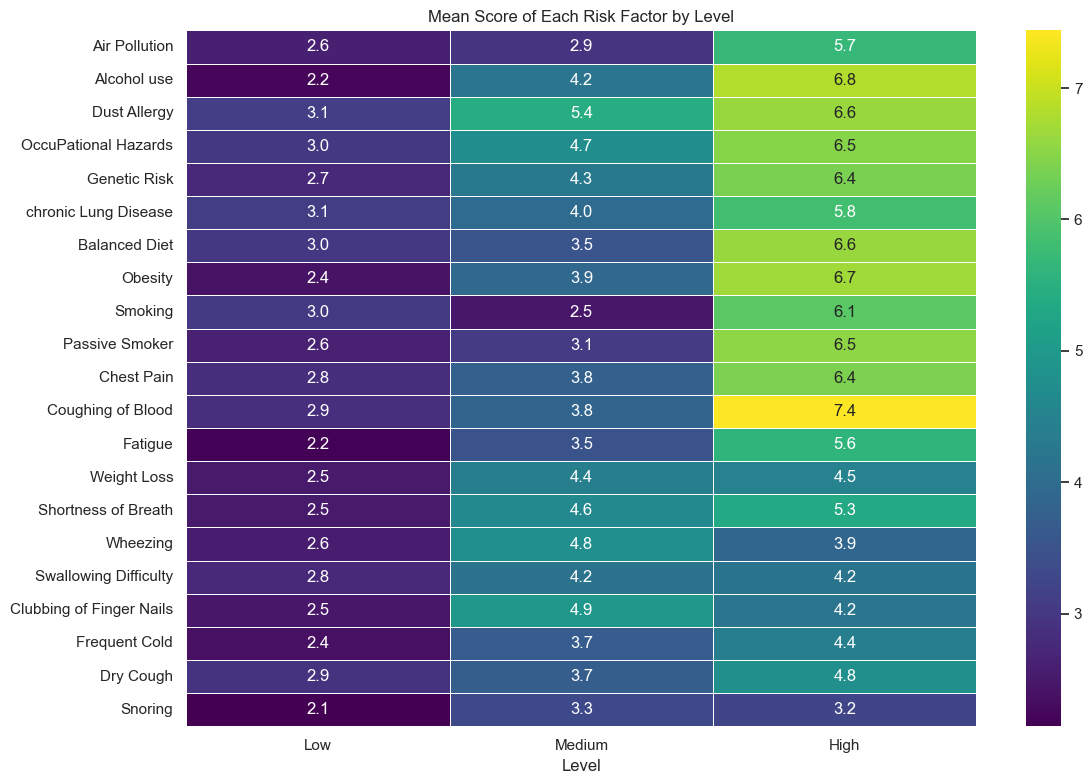

In [8]:
# Mean profile by level
risk_feats = [c for c in df.columns if c not in ['index', 'Patient Id', 'Age', 'Gender', 'Level']]

profile = df.groupby('Level', observed=True)[risk_feats].mean().reindex(order).T
print(profile.round(2))

plt.figure(figsize=(12, 8))
sns.heatmap(profile, annot=True, fmt='.1f', cmap='viridis', linewidths=0.5)
plt.title('Mean Score of Each Risk Factor by Level')
plt.tight_layout()
plt.show()

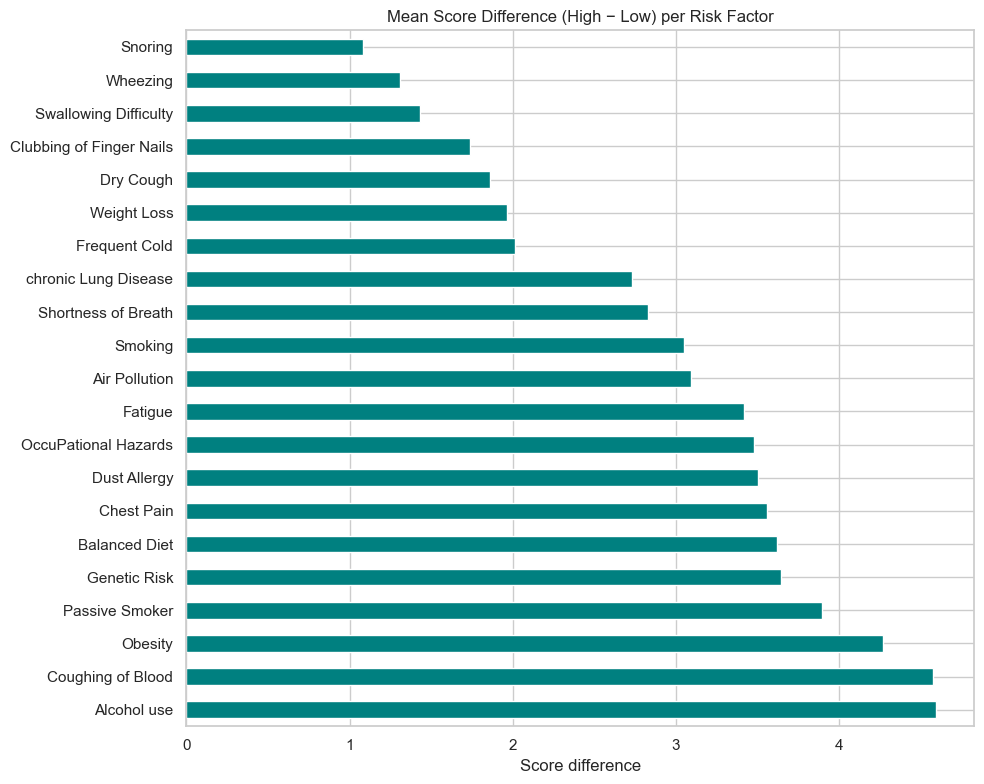

In [9]:
# Features that differ most between Low and High risk
diff = profile['High'] - profile['Low']
diff.sort_values(ascending=False).plot(kind='barh', figsize=(10, 8), color='teal')
plt.title('Mean Score Difference (High − Low) per Risk Factor')
plt.xlabel('Score difference')
plt.tight_layout()
plt.show()

### 4.4 Distribution of Key Risk Factors by Level

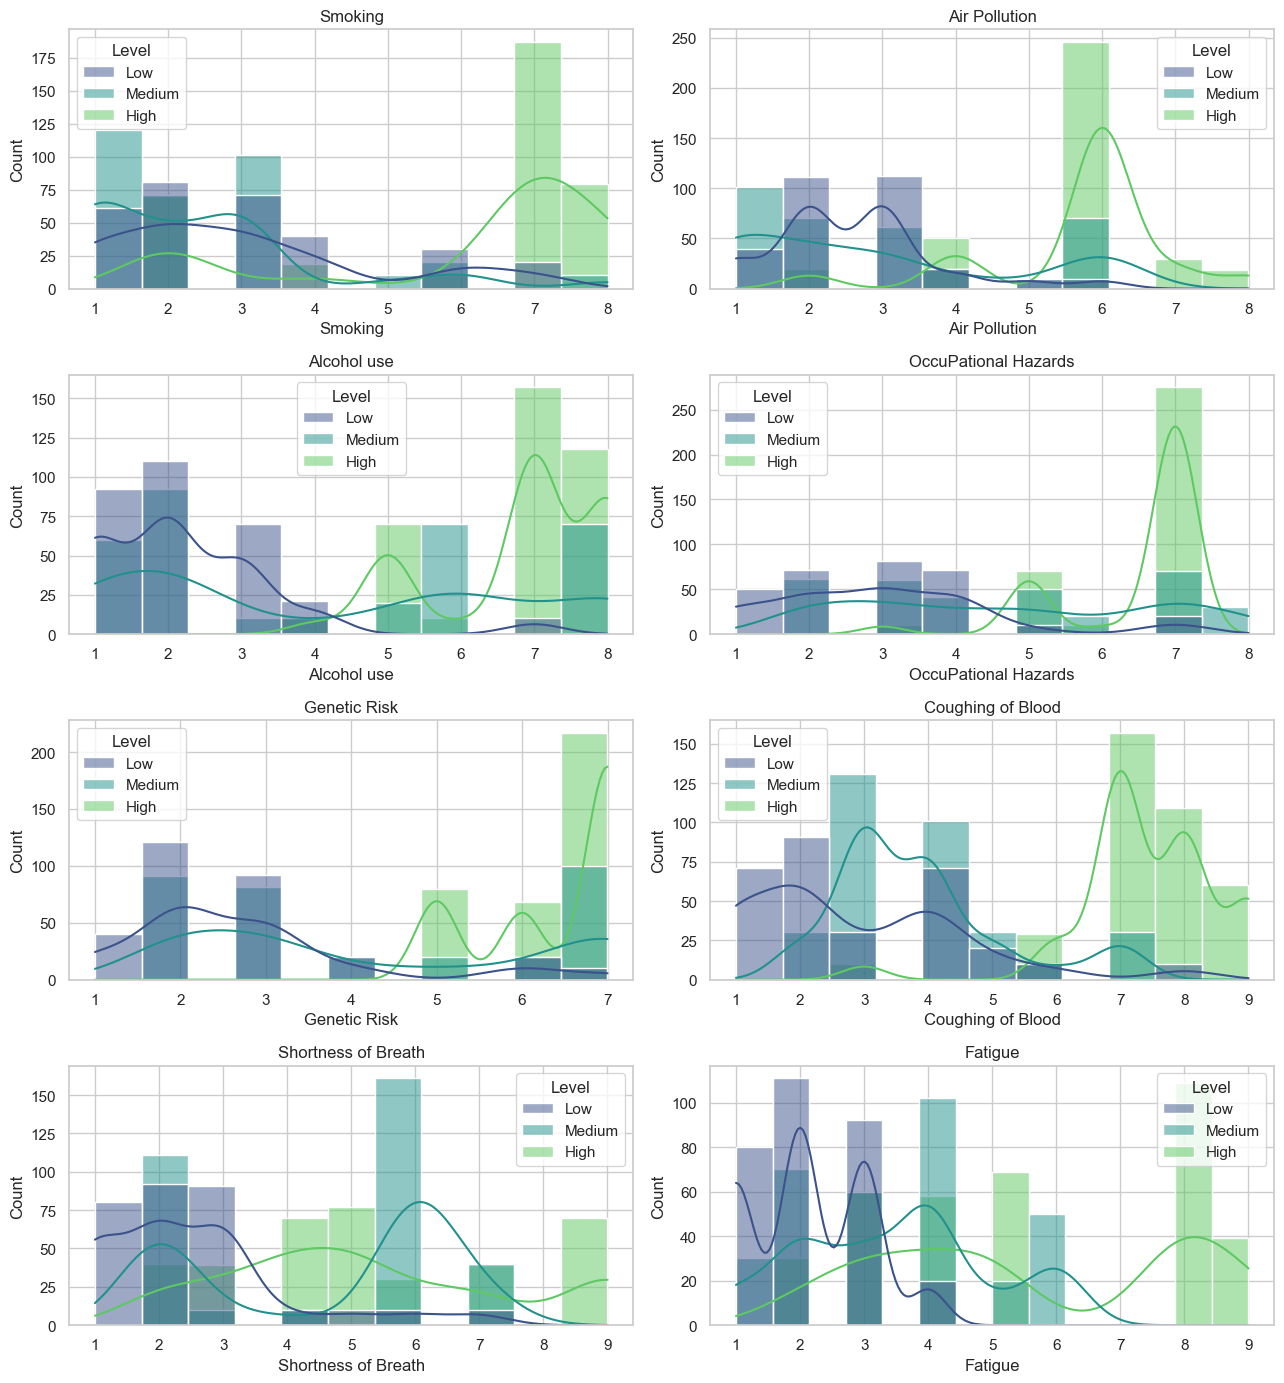

In [10]:
# Histograms of the most important factors
key = ['Smoking', 'Air Pollution', 'Alcohol use', 'OccuPational Hazards',
       'Genetic Risk', 'Coughing of Blood', 'Shortness of Breath', 'Fatigue']

fig, axes = plt.subplots(4, 2, figsize=(13, 14))
axes = axes.flatten()
for i, col in enumerate(key):
    sns.histplot(data=df, x=col, hue='Level', kde=True, ax=axes[i],
                 palette='viridis', alpha=0.5)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 4.5 Correlation Analysis

Correlation with Level:
Obesity                     0.827
Coughing of Blood           0.782
Alcohol use                 0.719
Dust Allergy                0.714
Balanced Diet               0.706
Passive Smoker              0.704
Genetic Risk                0.701
OccuPational Hazards        0.673
Chest Pain                  0.645
Air Pollution               0.636
Fatigue                     0.625
chronic Lung Disease        0.610
Smoking                     0.520
Shortness of Breath         0.497
Frequent Cold               0.444
Dry Cough                   0.374
Weight Loss                 0.353
Snoring                     0.289
Clubbing of Finger Nails    0.280
Swallowing Difficulty       0.249
Wheezing                    0.243
Age                         0.060
Gender                     -0.165
dtype: float64


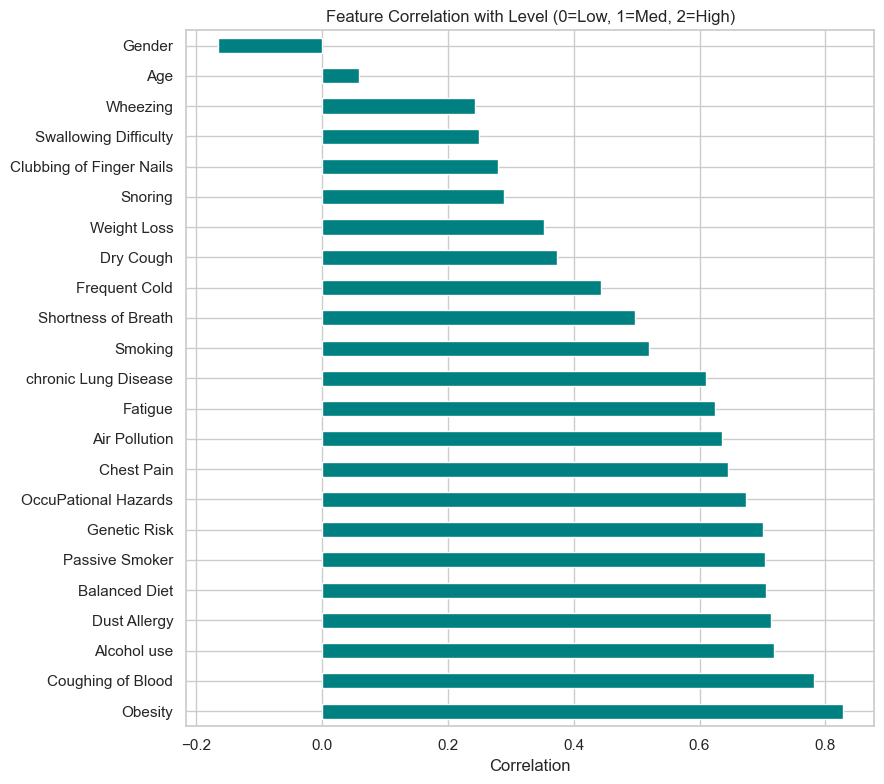

In [11]:
# Encode Level for correlation
df_enc = df.copy()
df_enc['Level'] = df_enc['Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

# Correlation with target
target_corr = df_enc[risk_feats + ['Age', 'Gender']].corrwith(df_enc['Level']).sort_values(ascending=False)
print('Correlation with Level:')
print(target_corr.round(3))

plt.figure(figsize=(9, 8))
target_corr.plot(kind='barh', color='teal')
plt.title('Feature Correlation with Level (0=Low, 1=Med, 2=High)')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

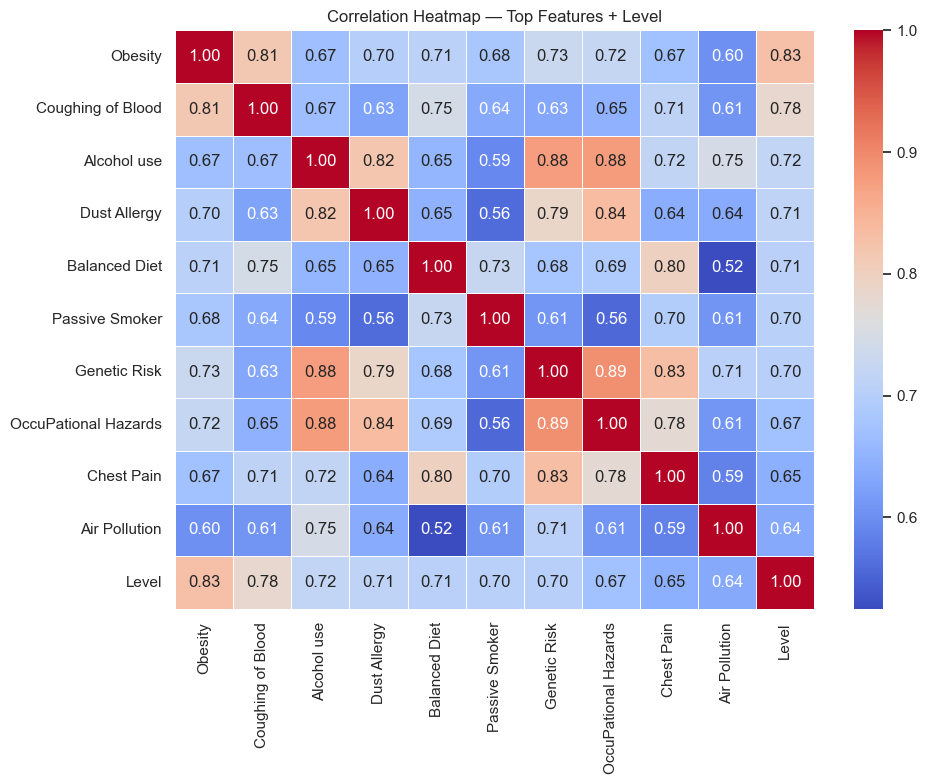

In [12]:
# Top risk factors correlation heatmap
top_feats = target_corr.abs().sort_values(ascending=False).head(10).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df_enc[top_feats + ['Level']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Top Features + Level')
plt.tight_layout()
plt.show()

## 5. Data Cleaning & Preprocessing

- No missing values, no duplicate rows.
- Drop the identifier columns (`index`, `Patient Id`) — not medically meaningful.
- All features are already numeric → no encoding needed.
- Target `Level` is a 3-class label (`Low`/`Medium`/`High`) — **multiclass classification**.

In [13]:
print('Rows:', len(df))
print('Missing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())

Rows: 1000
Missing values: 0
Duplicates: 0


In [14]:
# Drop identifier columns
df_clean = df.drop(['index', 'Patient Id'], axis=1)

# Features and target (keep Levels as strings for interpretable reports)
X = df_clean.drop('Level', axis=1)
y = df_clean['Level']

print('Features:', X.shape[1])
print('Feature names:', X.columns.tolist())
print('\nTarget classes:', np.unique(y))

Features: 23
Feature names: ['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']

Target classes: ['High' 'Low' 'Medium']


In [15]:
# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}')

Training set: (800, 23)
Test set: (200, 23)

Train target distribution:
Level
High      0.365
Medium    0.332
Low       0.302
Name: proportion, dtype: float64


## 6. Modelling Framework

We build a **ColumnTransformer + Pipeline** so that:
1. Missing values (if any) are imputed (`median`).
2. All numeric features are standardized with `StandardScaler`.
3. The pipeline runs through Stratified K-Fold cross-validation.

For this **multiclass** problem we score with accuracy, weighted-F1 and **ROC-AUC (One-vs-Rest, macro average)**.

In [16]:
# All features are numeric
numeric_features = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features)
])

print('Preprocessor defined')

Preprocessor defined


### 6.1 Cross-Validation Comparison of Baseline Models

In [17]:
# Define candidate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Extra Trees':         ExtraTreesClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f'{"Model":<20}{"Acc":<9}{"F1(w)":<9}{"ROC-AUC":<10}')
print('-' * 48)
for name, model in models.items():
    pipe = Pipeline([('prepro', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv5,
                            scoring={'accuracy': 'accuracy',
                                     'f1_weighted': 'f1_weighted',
                                     'roc_auc': roc_auc_ovr},
                            n_jobs=-1)
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'f1_weighted': scores['test_f1_weighted'].mean(),
        'roc_auc': scores['test_roc_auc'].mean()
    }
    print(f'{name:<20}{results[name]["accuracy"]:.3f}    {results[name]["f1_weighted"]:.3f}    {results[name]["roc_auc"]:.3f}')

best_base = max(results, key=lambda k: results[k]['roc_auc'])
print(f'\nBest baseline model: {best_base}')

Model               Acc      F1(w)    ROC-AUC   
------------------------------------------------


Logistic Regression 1.000    1.000    1.000


KNN                 1.000    1.000    1.000


Decision Tree       1.000    1.000    1.000


Random Forest       1.000    1.000    1.000
Extra Trees         1.000    1.000    1.000


Gradient Boosting   1.000    1.000    1.000
SVM                 1.000    1.000    1.000

Best baseline model: Logistic Regression


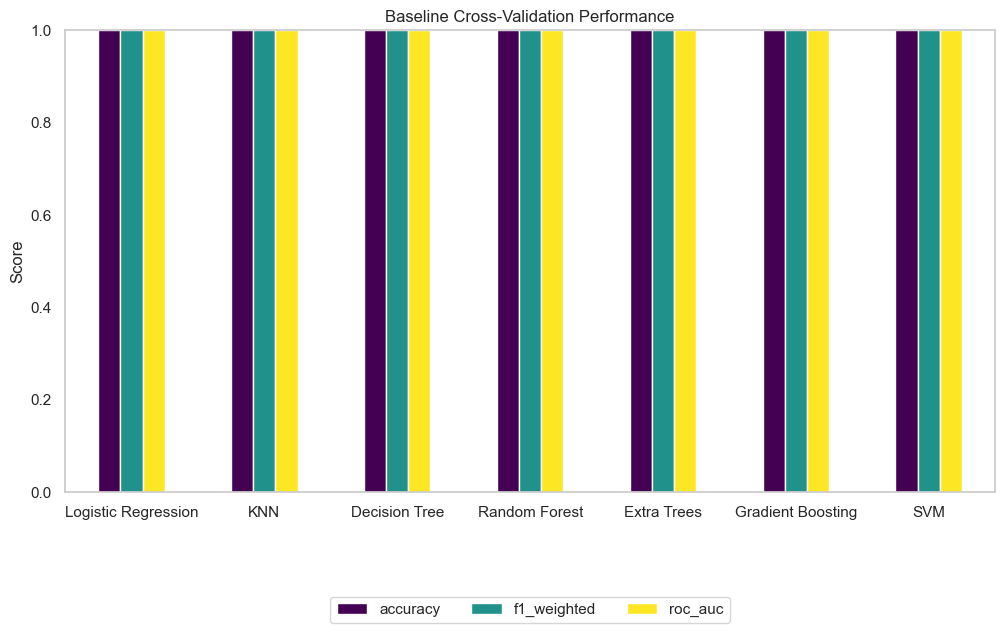

In [18]:
# Visualize baseline CV performance
baseline_df = pd.DataFrame(results).T
baseline_df.plot(kind='bar', figsize=(12, 6), rot=0, colormap='viridis')
plt.title('Baseline Cross-Validation Performance')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.grid(axis='y')
plt.show()

## 7. Hyperparameter Tuning (GridSearchCV)

The most promising models are tuned with 5-fold CV (small dataset — runs fast). Scoring = ROC-AUC (ovr/macro).

In [19]:
# Tune Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

pipe_rf = Pipeline([('prepro', preprocessor), ('model', RandomForestClassifier(random_state=42))])
rf_grid = GridSearchCV(pipe_rf, rf_param_grid, cv=cv5, scoring=roc_auc_ovr, n_jobs=-1)
rf_grid.fit(X_train, y_train)

print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(rf_grid.best_score_))

Best Random Forest params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 1.0000


In [20]:
# Tune Gradient Boosting
gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

pipe_gb = Pipeline([('prepro', preprocessor), ('model', GradientBoostingClassifier(random_state=42))])
gb_grid = GridSearchCV(pipe_gb, gb_param_grid, cv=cv5, scoring=roc_auc_ovr, n_jobs=-1)
gb_grid.fit(X_train, y_train)

print('Best Gradient Boosting params:', gb_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(gb_grid.best_score_))

Best Gradient Boosting params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV ROC-AUC: 1.0000


In [21]:
# Tune Extra Trees
et_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5]
}

pipe_et = Pipeline([('prepro', preprocessor), ('model', ExtraTreesClassifier(random_state=42))])
et_grid = GridSearchCV(pipe_et, et_param_grid, cv=cv5, scoring=roc_auc_ovr, n_jobs=-1)
et_grid.fit(X_train, y_train)

print('Best Extra Trees params:', et_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(et_grid.best_score_))

Best Extra Trees params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 1.0000


In [22]:
# Tune Logistic Regression
lr_param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs'],
    'model__max_iter': [3000]
}

pipe_lr = Pipeline([('prepro', preprocessor), ('model', LogisticRegression(random_state=42))])
lr_grid = GridSearchCV(pipe_lr, lr_param_grid, cv=cv5, scoring=roc_auc_ovr, n_jobs=-1)
lr_grid.fit(X_train, y_train)

print('Best Logistic Regression params:', lr_grid.best_params_)
print('Best CV ROC-AUC: {:.4f}'.format(lr_grid.best_score_))

Best Logistic Regression params: {'model__C': 1, 'model__max_iter': 3000, 'model__solver': 'lbfgs'}
Best CV ROC-AUC: 1.0000


## 8. Compare Tuned Models & Select the Best

The tuned estimators are re-scored with **5-fold Stratified CV** (ROC-AUC, macro ovr) and the winner is chosen.

In [23]:
# Collect tuned models
tuned_models = {
    'Random Forest':       rf_grid.best_estimator_,
    'Gradient Boosting':   gb_grid.best_estimator_,
    'Extra Trees':         et_grid.best_estimator_,
    'Logistic Regression': lr_grid.best_estimator_,
}

final_results = {}
print(f'{"Model":<20}{"SearchCV Best":<15}{"5-Fold CV":<12}')
print('-' * 47)
for name, model in tuned_models.items():
    grid_best = {'Random Forest': rf_grid, 'Gradient Boosting': gb_grid,
                 'Extra Trees': et_grid, 'Logistic Regression': lr_grid}[name].best_score_
    scores = cross_val_score(model, X_train, y_train, cv=cv5, scoring=roc_auc_ovr, n_jobs=-1)
    final_results[name] = scores.mean()
    print(f'{name:<20}{grid_best:.4f}        {scores.mean():.4f}')

best_name = max(final_results, key=final_results.get)
best_model = tuned_models[best_name]
print(f'\n🏆 Best model: {best_name} (5-fold CV ROC-AUC = {final_results[best_name]:.4f})')

Model               SearchCV Best  5-Fold CV   
-----------------------------------------------
Random Forest       1.0000        1.0000


Gradient Boosting   1.0000        1.0000
Extra Trees         1.0000        1.0000
Logistic Regression 1.0000        1.0000

🏆 Best model: Random Forest (5-fold CV ROC-AUC = 1.0000)


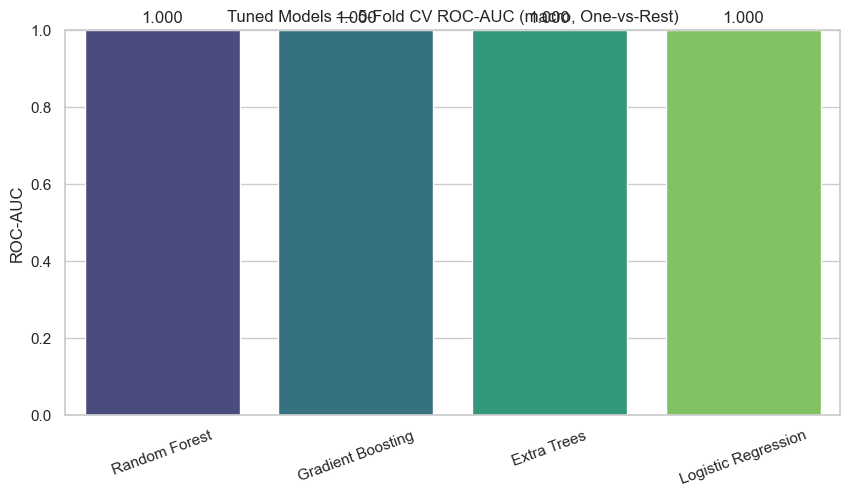

In [24]:
# Plot comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(final_results.keys()), y=list(final_results.values()), palette='viridis')
plt.title('Tuned Models — 5-Fold CV ROC-AUC (macro, One-vs-Rest)')
plt.ylabel('ROC-AUC')
plt.ylim(0, 1)
plt.xticks(rotation=20)
for i, v in enumerate(final_results.values()):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.show()

## 9. Evaluate the Best Model on the Holdout Test Set

In [25]:
# Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred))

print('Metrics:')
print(f'Accuracy    : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 (macro)  : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'F1 (weighted): {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'ROC-AUC (ovr macro): {roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"):.4f}')

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Metrics:
Accuracy    : 1.0000
F1 (macro)  : 1.0000
F1 (weighted): 1.0000
ROC-AUC (ovr macro): 1.0000


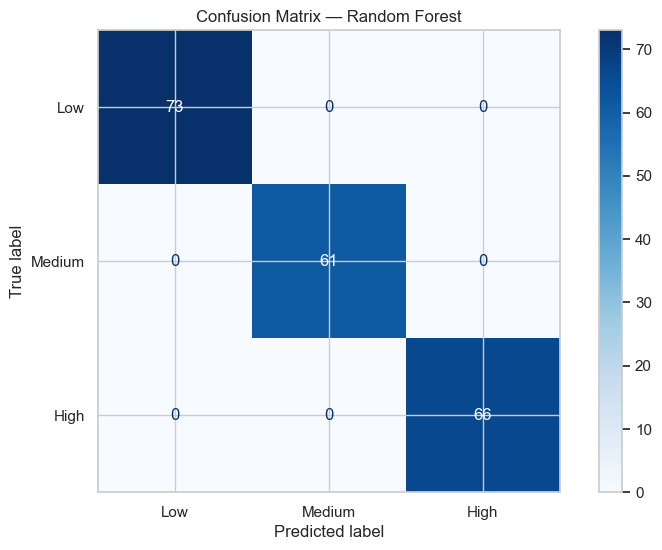

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

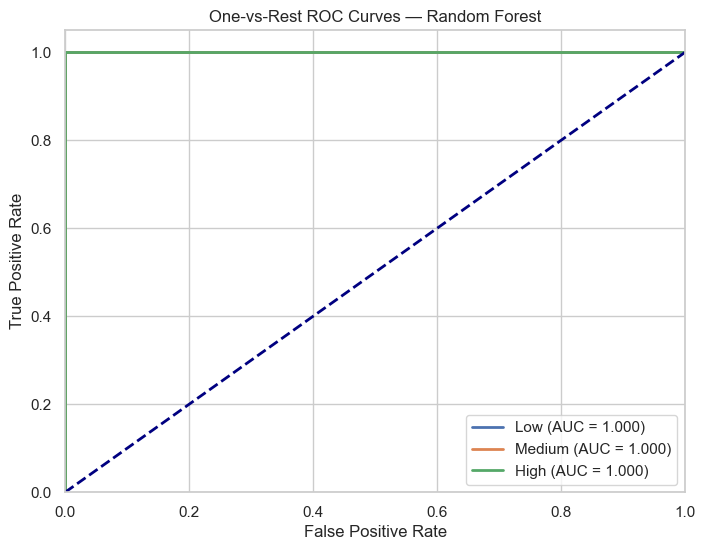

In [27]:
# One-vs-Rest ROC curves for each class
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

plt.figure(figsize=(8, 6))
for i, cls in enumerate(['Low', 'Medium', 'High']):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_txt = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{cls} (AUC = {auc_txt:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'One-vs-Rest ROC Curves — {best_name}')
plt.legend(loc='lower right'); plt.grid(True)
plt.show()

## 10. Feature Importance (for the best tree-based model)

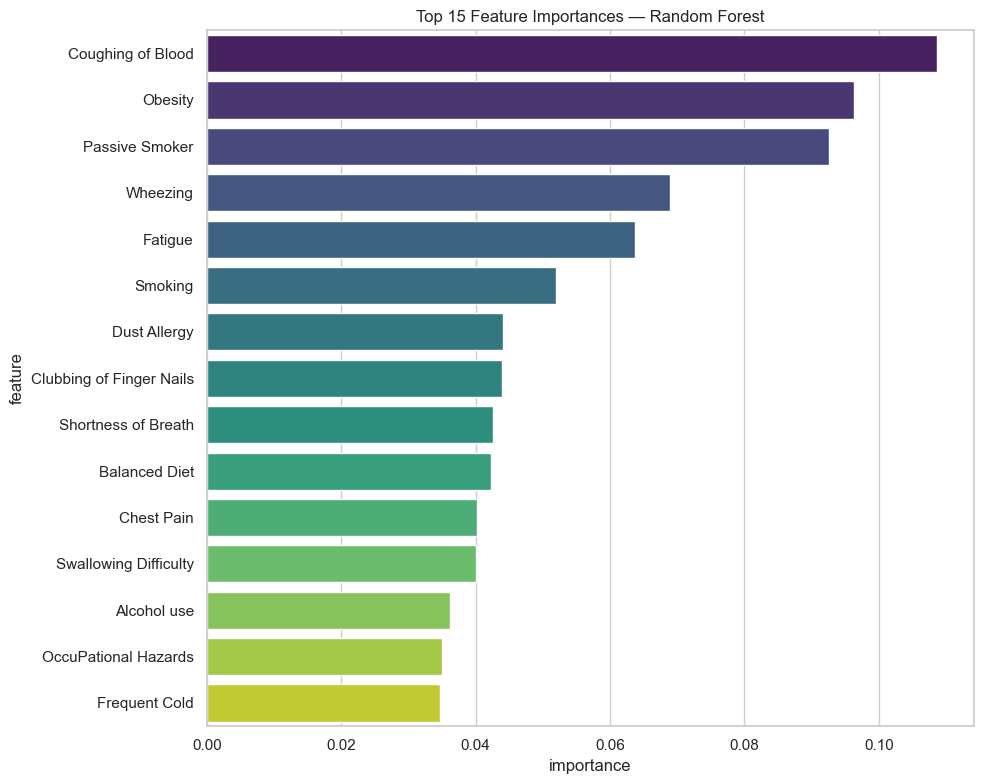

In [28]:
# Feature importance if tree-based
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    importances = best_model.named_steps['model'].feature_importances_
    feat_names = X_train.columns
    imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df.head(15), x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_name} is not a tree-based model; feature importance not available directly.')

## 11. Conclusion & Summary

- **Dataset**: 1,000 patients, 24 features + target (`Level`). No missing values, no duplicate rows.
- **Target**: **3-class multiclass** — `Low` (30%), `Medium` (33%), `High` (37%) — fairly balanced.
- **Cleaning**: dropped identifier columns `index` & `Patient Id`; all features numeric; no encoding needed.
- **Best model**: selected via GridSearchCV tuning + 5-fold Stratified CV, judged by macro One-vs-Rest ROC-AUC.

### Key findings from EDA:
- **Smoking, Air Pollution, Alcohol use, Occupational Hazards** and **Genetic Risk** are the strongest risk drivers (mean scores climb from Low → Medium → High).
- Among symptoms, **Coughing of Blood**, **Shortness of Breath**, **Fatigue** and **Weight Loss** most strongly separate risk levels.
- Older patients tend toward higher risk levels (positive Age–Level correlation).

In [29]:
from IPython.display import display, Markdown

display(Markdown(f'''
## Final Model
- **Best model**: **{best_name}** with a 5-fold CV ROC-AUC (macro, ovr) of **{final_results[best_name]:.3f}**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, fully reusable and deployment-ready.
- Test-set ROC-AUC (macro, ovr): **{roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"):.3f}**
'''))


## Final Model
- **Best model**: **Random Forest** with a 5-fold CV ROC-AUC (macro, ovr) of **1.000**.
- All preprocessing (imputation + scaling) is encapsulated in an sklearn `Pipeline`, fully reusable and deployment-ready.
- Test-set ROC-AUC (macro, ovr): **1.000**


In [30]:
# Save the full pipeline for reuse
import joblib
joblib.dump(best_model, 'best_lung_cancer_model.pkl')
print(f'Saved best pipeline ({best_name}) to best_lung_cancer_model.pkl')
print('\nPipeline:')
print(best_model)

Saved best pipeline (Random Forest) to best_lung_cancer_model.pkl

Pipeline:
Pipeline(steps=[('prepro',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Gender',
                                                   'Air Pollution',
                                                   'Alcohol use',
                                                   'Dust Allergy',
                                                   'OccuPational Hazards',
                                                   'Genetic Risk',
                                                   'chronic Lung Disease',
        